In [2]:
from typing import TypedDict

class PortfolioState(TypedDict):
    amount_usd: float
    total_usd: float
    total_inr : float

In [3]:
# Define Nodes
# Which is nothing but simple python functions
def calc_total(state:PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def calc_total_inr(state:PortfolioState) -> PortfolioState :
    state['total_inr'] = state['total_usd'] * 85
    return state

In [4]:
from langgraph.graph import StateGraph, START, END

# builder is something that will let you define that graph
builder = StateGraph(PortfolioState)

builder.add_node("calculate_total_amount", calc_total)
builder.add_node("convert_currency_to_inr_amount", calc_total_inr)

builder.add_edge(START, "calculate_total_amount")
builder.add_edge("calculate_total_amount", "convert_currency_to_inr_amount")
builder.add_edge("convert_currency_to_inr_amount", END)

graph = builder.compile()

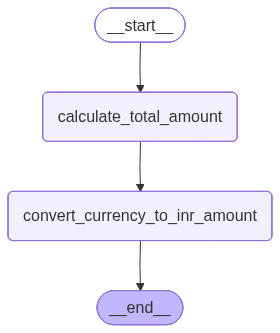

In [7]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
from typing import cast
graph.invoke(cast(PortfolioState, {"amount_usd": 1000}))

{'amount_usd': 1000, 'total_usd': 1080.0, 'total_inr': 91800.0}